In [ ]:
import os

# 1. Kaggle Access Token
os.environ['KAGGLE_API_TOKEN'] = "KGAT_88761684907cf4212adb325b8035e0e8"

# 2. Install required packages
!pip install -q roboflow kaggle
print("Authenticated and ready!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 122.3 MB/s eta 0:00:00
Authenticated and ready!


In [ ]:
# Dataset A: NEW Obstacles Detection Dataset (by Nayan Bebale)
print("Downloading Dataset A...")
!kaggle datasets download -d nayanbebale/obstacles-detection-datasets-yolo

# Dataset B: Potholes, Cracks, and Open Manholes / Road Hazards (by Sabid Rahman)
print("Downloading Dataset B...")
!kaggle datasets download -d sabidrahman/pothole-cracks-and-openmanhole

# Create the folders safely
!mkdir -p dataset_A
!mkdir -p dataset_B

# Unzip Dataset A
print("Unzipping Dataset A...")
!unzip -q obstacles-detection-datasets-yolo.zip -d dataset_A

# Unzip Dataset B
print("Unzipping Dataset B...")
!unzip -q pothole-cracks-and-openmanhole.zip -d dataset_B

print("Data unzipped and ready for Roboflow!")

Dataset URL: https://www.kaggle.com/datasets/nayanbebale/obstacles-detection-datasets-yolo
License(s): other
obstacles-detection-datasets-yolo.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/sabidrahman/pothole-cracks-and-openmanhole
License(s): CC-BY-NC-SA-4.0
Resuming from 599785472 bytes (478470837 bytes left)...
100% 1.00G/1.00G [00:06<00:00, 75.4MB/s]

Unzipping Dataset A...
replace dataset_A/test/images/gambar-1002-_jpg.rf.3ef8fcc278fbb6a46fae85a1930c2103.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
Unzipping Dataset B...
Data unzipped and ready for Roboflow!


In [ ]:
from roboflow import Roboflow

# Connect to your Roboflow account
rf = Roboflow(api_key="p9J3iDG7hMzKFWpNI8sI")

# Define your workspace
workspace = rf.workspace("alexs-workspace-rs5vl")

# IMPORTANT: We are using a NEW project name so it doesn't mix with your old images
NEW_PROJECT_NAME = "visually_impaired_ai_v2"

# Upload NEW Dataset A (Nayan Bebale Obstacles)
print("Uploading Dataset A...")
workspace.upload_dataset(
    dataset_path="dataset_A",
    project_name=NEW_PROJECT_NAME,
    dataset_format="yolov8",
    project_type="object-detection"
)

# Upload Dataset B (Road Hazards)
print("Uploading Dataset B...")
workspace.upload_dataset(
    dataset_path="dataset_B",
    project_name=NEW_PROJECT_NAME,
    dataset_format="yolov8",
    project_type="object-detection"
)

print("Upload to Roboflow complete!")

loading Roboflow workspace...
Uploading Dataset A...
loading Roboflow project...
Uploading to existing project alexs-workspace-rs5vl/visually_impaired_ai_v2
[UPLOADED] dataset_A/test/images/gambar-1056-_jpg.rf.ee848035562b86fe1077888497bc32b0.jpg (8DEzwMbu7IorKKay6FFB) [1.1s] / annotations = OK [0.5s]
[UPLOADED] dataset_A/test/images/gambar-1023-_jpg.rf.5f1e3ea14830947d14e7aa1311d16650.jpg (67mwjbcqviLAkmYEBReb) [1.1s] / annotations = OK [0.6s]
[UPLOADED] dataset_A/test/images/gambar-1058-_jpg.rf.3f11ec08510fda9e52a79d85b72e49cf.jpg (Ln4kX9axvE6KKMXMKMLq) [1.1s] / annotations = OK [0.6s]
[UPLOADED] dataset_A/test/images/gambar-1002-_jpg.rf.3ef8fcc278fbb6a46fae85a1930c2103.jpg (HiuN9K5sQYbDG3Z2RGjr) [1.2s] / annotations = OK [0.6s]
[UPLOADED] dataset_A/test/images/gambar-1032-_jpg.rf.814bc12b282ff6cbb4519a596922b99c.jpg (YMtb5AyinhPKnlK96bqv) [1.5s] / annotations = OK [0.4s]
[UPLOADED] dataset_A/test/images/gambar-1055-_jpg.rf.59b99da97fc8af6990dd9fe228be109b.jpg (Nwm5oN6fDigsMBK9d8El) 

KeyboardInterrupt: 

## **New dataset after using Roboflow**

In [ ]:
# 1. Install libraries
!pip install -q roboflow ultralytics

# 2. Download your clean dataset from Roboflow
from roboflow import Roboflow
rf = Roboflow(api_key="p9J3iDG7hMzKFWpNI8sI")
project = rf.workspace("alexs-workspace-rs5vl").project("visually_impaired_ai_v2")
version = project.version(1)
dataset = version.download("yolov8")

# 3. Train the AI!
from ultralytics import YOLO

# Load the lightweight AI model
model = YOLO('yolov8n.pt')

# Train it on your massive new dataset
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=25,
    imgsz=640,
    plots=True
)

In [ ]:
import glob
import os
from ultralytics import YOLO
from IPython.display import display, Image

# 1. Automatically find the NEWEST 'best.pt' file (in case YOLO saved it in train2 or train3)
weight_files = glob.glob('runs/detect/train*/weights/best.pt')
latest_weights = max(weight_files, key=os.path.getctime)
print(f"Loading AI brain from: {latest_weights}")

# 2. Look specifically inside your new V2 dataset and grab image #99
image_list = glob.glob('visually_impaired_ai_v2-*/valid/images/*.jpg')

# Safety check: make sure we actually found images before trying to load one
if len(image_list) > 99:
    my_test_image = image_list[701]
    print(f"Success! Found a test image: {my_test_image}")

    # 3. Load your freshly trained AI
    model = YOLO(latest_weights)

    # 4. Tell the AI to look at the image and draw boxes
    results = model.predict(source=my_test_image, save=True)

    # 5. Grab the file name so we can display it
    image_name = my_test_image.split('/')[-1]

    # 6. Display the final result right here in the notebook!
    display(Image(filename=f"{results[0].save_dir}/{image_name}"))
else:
    print("Oops! Couldn't find the images. Double-check that the dataset downloaded correctly.")

Mounting to google drive

In [ ]:
import os

# 1. Create a backup folder in Google Drive
os.makedirs('/content/drive/MyDrive/YOLO_Sensor_Backup', exist_ok=True)

# 2. Copy latest training run into that folder
# (The -r flag means "recursive", so it grabs the folder and everything inside it)
!cp -r runs/detect/train /content/drive/MyDrive/YOLO_Sensor_Backup/

print("Success! Your AI brain and graphs are safely backed up to Google Drive.")

Now , we don't need to train every single time and we just use the code below

In [ ]:
!pip install -q roboflow ultralytics

Mounted at /content/drive
Loading AI Brain...
AI is awake and ready!
Testing image: /content/drive/MyDrive/Test_Images/img-val/0524073.jpg

image 1/1 /content/drive/MyDrive/Test_Images/img-val/0524073.jpg: 640x480 1 2, 10.5ms
Speed: 3.7ms preprocess, 10.5ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict-2


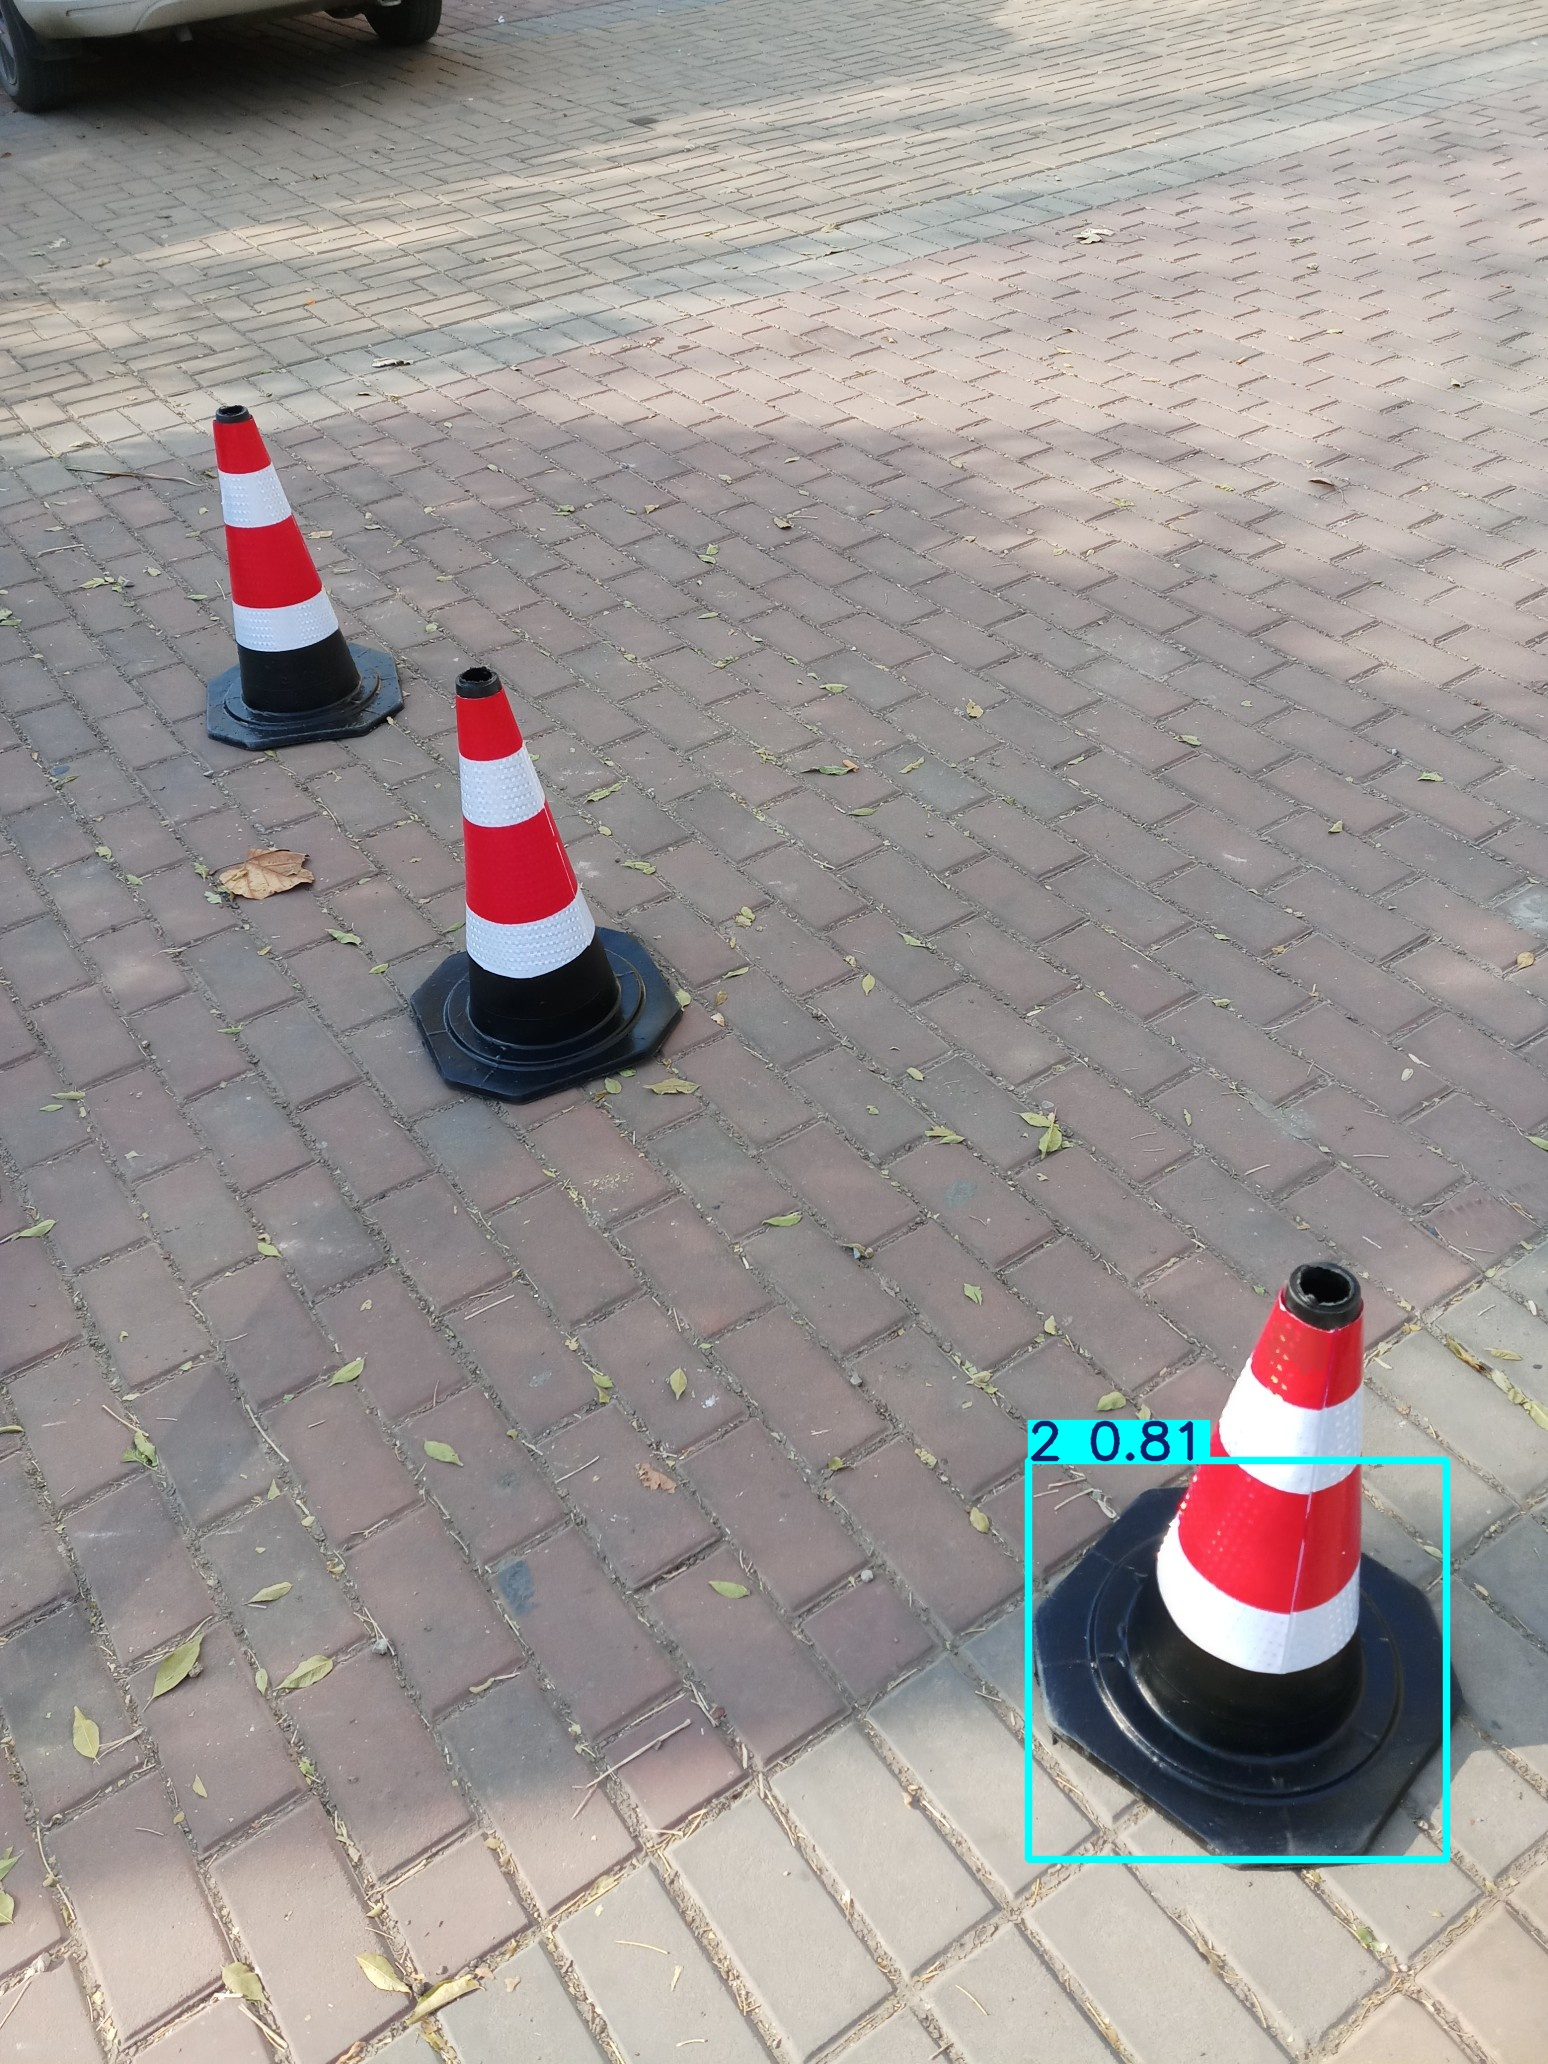

In [ ]:
# 1. Install YOLO
!pip install -q ultralytics

# 2. Connect to your Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 3. Wake up your AI!
from ultralytics import YOLO
from IPython.display import display, Image
import glob

print("Loading AI Brain...")
model = YOLO('/content/drive/MyDrive/YOLO_Sensor_Backup/train/weights/best.pt')
print("AI is awake and ready!")

# 4. FIXED PATH: Look directly inside the 'img-val' subfolder
image_list = []
for ext in ('*.jpg', '*.jpeg', '*.png'):
    image_list.extend(glob.glob(f'/content/drive/MyDrive/Test_Images/img-val/{ext}'))

# 5. Run prediction if an image exists
if len(image_list) > 0:
    # Let's test the very first image (0000222.jpg)!
    # Change [0] to [1], [2], [3], etc. to test different photos in that list!
    my_image_path = image_list[2]
    print(f"Testing image: {my_image_path}")

    results = model.predict(source=my_image_path, save=True)
    image_name = my_image_path.split('/')[-1]
    display(Image(filename=f"{results[0].save_dir}/{image_name}"))
else:
    print("Oops! Still couldn't find the images. Make sure the path spelling matches exactly.")

Testing a new image: /content/drive/MyDrive/Test_Images/img-val/0518061.jpg

image 1/1 /content/drive/MyDrive/Test_Images/img-val/0518061.jpg: 640x480 1 9, 9.3ms
Speed: 2.8ms preprocess, 9.3ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict-2


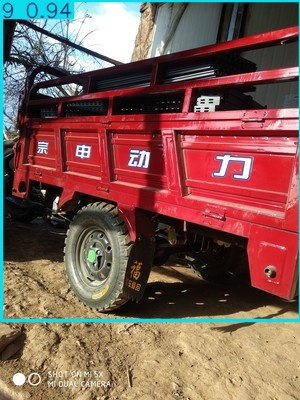

In [ ]:
# Try a different image index in the list (e.g., 5, 12, 20)
my_image_path = image_list[65]
print(f"Testing a new image: {my_image_path}")

# Run prediction with a lower confidence threshold to catch trickier objects
results = model.predict(source=my_image_path, save=True, conf=0.10)

# Show the new result
image_name = my_image_path.split('/')[-1]
display(Image(filename=f"{results[0].save_dir}/{image_name}"))

Adapting code to webapp for phone

In [ ]:
# 0. INSTALL PIPER & DOWNLOAD VOICE MODEL
!pip install -q ultralytics fastapi uvicorn pyngrok nest_asyncio piper-tts
!wget -q https://huggingface.co/rhasspy/piper-voices/resolve/v1.0.0/en/en_US/lessac/medium/en_US-lessac-medium.onnx
!wget -q https://huggingface.co/rhasspy/piper-voices/resolve/v1.0.0/en/en_US/lessac/medium/en_US-lessac-medium.onnx.json

# 1. Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 2. Standard Imports
import os
import io
import wave
import base64
import nest_asyncio
import uvicorn
from PIL import Image
from fastapi import FastAPI, File, UploadFile
from fastapi.middleware.cors import CORSMiddleware
from ultralytics import YOLO
from pyngrok import ngrok
from google.colab import userdata
from piper import PiperVoice

# 3. Setup FastAPI
app = FastAPI()
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"]
)

# 4. Load Models (YOLO Brain + Piper Voice)
model_path = '/content/drive/MyDrive/YOLO_Sensor_Backup/train/weights/best.pt'
if os.path.exists(model_path):
    model = YOLO(model_path)
    print(f"✅ YOLO Brain Loaded Successfully!")
else:
    print(f"❌ Error: Could not find your YOLO model!")

print("🎤 Loading Piper Voice Model...")
voice = PiperVoice.load("en_US-lessac-medium.onnx")
print("✅ Voice Ready!")

# 5. OUR UPDATED TRUE DICTIONARY
CUSTOM_LABELS = {
    0: "pothole", 1: "cracks in the road", 2: "open manhole", 3: "vendor",
    4: "curb", 5: "crack in the road", 6: "trash bin", 7: "bench",
    8: "open manhole", 9: "car", 10: "motorcycle", 11: "person",
    12: "fence or wall", 13: "barrier", 14: "road work obstacle",
    15: "door", 16: "tree", 17: "flower pot", 18: "sewer",
    19: "stairs", 20: "pole", 21: "crosswalk"
}

# 6. THE PREDICTION API (WITH AUDIO GENERATION)
@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    contents = await file.read()
    img = Image.open(io.BytesIO(contents))

    # Using 0.20 confidence to prevent the AI from being too shy
    results = model(img, conf=0.20)

    detections = []
    unique_labels = []

    for box in results[0].boxes:
        class_id = int(box.cls)
        real_word = CUSTOM_LABELS.get(class_id, f"Unknown Object ({class_id})")
        coords = box.xyxy[0].tolist()

        detections.append({
            "label": real_word,
            "box": coords
        })

        if real_word not in unique_labels:
            unique_labels.append(real_word)

    # PIPER AUDIO GENERATION
    audio_b64 = None
    if unique_labels:
        warning_text = "Warning: " + " and ".join(unique_labels[:2])

        wav_io = io.BytesIO()
        with wave.open(wav_io, 'wb') as wav_file:
            voice.synthesize(warning_text, wav_file)

        audio_b64 = base64.b64encode(wav_io.getvalue()).decode('utf-8')

    return {"detections": detections, "audio": audio_b64}

# 7. The "Safety First" ngrok Startup
def start_ngrok():
    try:
        my_token = userdata.get('NGROK_TOKEN')
        ngrok.kill()
        ngrok.set_auth_token(my_token)
        url = ngrok.connect(8000).public_url
        print(f"\n🚀 API LIVE AT: {url}")
        print(f"🔗 Update your VS Code HTML with: {url}/predict")
        return url
    except Exception as e:
        print(f"❌ Ngrok Error: {e}")
        return None

if __name__ == "__main__":
    public_url = start_ngrok()
    if public_url:
        nest_asyncio.apply()
        config = uvicorn.Config(app, host="0.0.0.0", port=8000, log_level="info")
        server = uvicorn.Server(config)
        await server.serve()

Mounted at /content/drive
✅ YOLO Brain Loaded Successfully!
🎤 Loading Piper Voice Model...
✅ Voice Ready!

🚀 API LIVE AT: https://purchase-tissue-wrench.ngrok-free.dev
🔗 Update your VS Code HTML with: https://purchase-tissue-wrench.ngrok-free.dev/predict


INFO:     Started server process [764]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)



0: 640x480 (no detections), 9.1ms
Speed: 1.5ms preprocess, 9.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 480)
INFO:     147.83.201.171:0 - "POST /predict HTTP/1.1" 200 OK

0: 640x480 (no detections), 6.6ms
Speed: 1.4ms preprocess, 6.6ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)
INFO:     147.83.201.171:0 - "POST /predict HTTP/1.1" 200 OK

0: 640x480 (no detections), 6.6ms
Speed: 1.3ms preprocess, 6.6ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 480)
INFO:     147.83.201.171:0 - "POST /predict HTTP/1.1" 200 OK

0: 640x480 (no detections), 6.4ms
Speed: 1.4ms preprocess, 6.4ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 480)
INFO:     147.83.201.171:0 - "POST /predict HTTP/1.1" 200 OK

0: 640x480 1 9, 6.3ms
Speed: 1.3ms preprocess, 6.3ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)
INFO:     147.83.201.171:0 - "POST /predict HTTP/1.1" 500 Internal Server Error


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error


0: 640x480 (no detections), 6.6ms
Speed: 1.4ms preprocess, 6.6ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)
INFO:     147.83.201.171:0 - "POST /predict HTTP/1.1" 200 OK

0: 640x480 (no detections), 6.3ms
Speed: 1.4ms preprocess, 6.3ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)
INFO:     147.83.201.171:0 - "POST /predict HTTP/1.1" 200 OK

0: 640x480 (no detections), 6.2ms
Speed: 1.3ms preprocess, 6.2ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 480)
INFO:     147.83.201.171:0 - "POST /predict HTTP/1.1" 200 OK

0: 640x480 (no detections), 6.1ms
Speed: 1.3ms preprocess, 6.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 480)
INFO:     147.83.201.171:0 - "POST /predict HTTP/1.1" 200 OK

0: 640x480 (no detections), 8.3ms
Speed: 1.8ms preprocess, 8.3ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)
INFO:     147.83.201.171:0 - "POST /predict HTTP/1.1" 200 OK

0: 640x480 (no detections), 6.8ms
Speed

...


0: 640x480 1 9, 7.8ms
Speed: 2.8ms preprocess, 7.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)
INFO:     147.83.201.171:0 - "POST /predict HTTP/1.1" 500 Internal Server Error


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error


0: 640x480 (no detections), 6.3ms
Speed: 1.4ms preprocess, 6.3ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 480)
INFO:     147.83.201.171:0 - "POST /predict HTTP/1.1" 200 OK

0: 640x480 (no detections), 6.6ms
Speed: 1.5ms preprocess, 6.6ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 480)
INFO:     147.83.201.171:0 - "POST /predict HTTP/1.1" 200 OK

0: 640x480 (no detections), 6.2ms
Speed: 1.5ms preprocess, 6.2ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 480)
INFO:     147.83.201.171:0 - "POST /predict HTTP/1.1" 200 OK

0: 640x480 (no detections), 6.2ms
Speed: 1.2ms preprocess, 6.2ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 480)
INFO:     147.83.201.171:0 - "POST /predict HTTP/1.1" 200 OK

0: 640x480 1 9, 6.2ms
Speed: 1.4ms preprocess, 6.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)
INFO:     147.83.201.171:0 - "POST /predict HTTP/1.1" 500 Internal Server Error


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error


0: 640x480 (no detections), 6.4ms
Speed: 1.7ms preprocess, 6.4ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 480)
INFO:     147.83.201.171:0 - "POST /predict HTTP/1.1" 200 OK

0: 640x480 (no detections), 7.4ms
Speed: 1.4ms preprocess, 7.4ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)
INFO:     147.83.201.171:0 - "POST /predict HTTP/1.1" 200 OK

0: 640x480 (no detections), 6.3ms
Speed: 1.3ms preprocess, 6.3ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 480)
INFO:     147.83.201.171:0 - "POST /predict HTTP/1.1" 200 OK

0: 640x480 (no detections), 6.7ms
Speed: 1.4ms preprocess, 6.7ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)
INFO:     147.83.201.171:0 - "POST /predict HTTP/1.1" 200 OK

0: 640x480 (no detections), 12.6ms
Speed: 2.4ms preprocess, 12.6ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 480)
INFO:     147.83.201.171:0 - "POST /predict HTTP/1.1" 200 OK

0: 640x480 (no detections), 8.7ms
Spe